# Dense vs Convolutional Networks: MNIST, Fashion-MNIST, and CIFAR-10

This notebook compares **dense feed-forward neural networks and convolutional neural networks** on image-classification datasets with increasing visual complexity. It also compares optimizer choices, label encodings, and CNN depth so that the effect of architecture can be separated from training choices.

### Main comparisons
- Dense network vs CNN
- SGD with momentum vs Adam
- Sparse labels vs one-hot labels
- Compact CNN vs simpler CNN
- Compact CNN vs deeper VGG-style CNN
- Performance changes from MNIST to Fashion-MNIST to CIFAR-10

### Progression
1. Dense-network baselines
2. SGD with momentum vs Adam
3. Sparse-label and one-hot label formulations
4. Compact CNNs
5. A simpler CNN without an intermediate dense hidden layer
6. A deeper VGG-style CNN

The same datasets are reused so that the effect of architecture is easier to compare.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.utils import plot_model

In [2]:
def plot_results(history):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

    ax[0].plot(history.history["accuracy"], label="train")
    ax[0].plot(history.history["val_accuracy"], label="validation")
    ax[0].set_title("Accuracy")
    ax[0].legend()

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="validation")
    ax[1].set_title("Loss")
    ax[1].legend()

    plt.show()


def print_best_metrics(h):
    metrics = [
        ("training accuracy", "accuracy", np.argmax),
        ("validation accuracy", "val_accuracy", np.argmax),
        ("training loss", "loss", np.argmin),
        ("validation loss", "val_loss", np.argmin),
    ]

    for label, key, selector in metrics:
        values = np.asarray(h[key])
        idx = int(selector(values))
        qualifier = "highest" if "accuracy" in label else "lowest"
        print(f"The {qualifier} {label} was {values[idx]:.4f} at epoch {idx + 1}")
        print(f"The final {label} was {values[-1]:.4f}")


def load_dataset(name, add_channel=False):
    if name == "MNIST":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    elif name == "Fashion-MNIST":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    elif name == "CIFAR-10":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    else:
        raise ValueError("Unknown dataset")

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    if add_channel and x_train.ndim == 3:
        x_train = np.expand_dims(x_train, -1)
        x_test = np.expand_dims(x_test, -1)

    return x_train, y_train, x_test, y_test

## 2. Dense-Network Baselines

In [3]:
def dense_model(input_shape=(28, 28), hidden=(500,)):
    model = Sequential([Input(shape=input_shape), Flatten()])

    for units in hidden:
        model.add(Dense(units, activation="relu"))

    model.add(Dense(10, activation="softmax"))
    return model

### 2.1 MNIST: SGD + Momentum vs Adam

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,010 (2.47 MB)

 Trainable params: 648,010 (2.47 MB)

 Non-trainable params: 0 (0.00 B)


Optimizer: SGD
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8819 - loss: 0.4275 - val_accuracy: 0.9295 - val_loss: 0.2482
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9366 - loss: 0.2243 - val_accuracy: 0.9457 - val_loss: 0.1899
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9505 - loss: 0.1744 - val_accuracy: 0.9542 - val_loss: 0.1572
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9607 - loss: 0.1426 - val_accuracy: 0.9624 - val_loss: 0.1321
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9668 - loss: 0.1206 - val_accuracy: 0.9666 - val_loss: 0.1175
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9714 - loss: 0.1039 - val_accuracy: 0.9680 - val_loss: 0.1096
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9745 - loss: 0.0919 - val_accuracy: 0.9706 - val_loss: 0.0994
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0812 - 

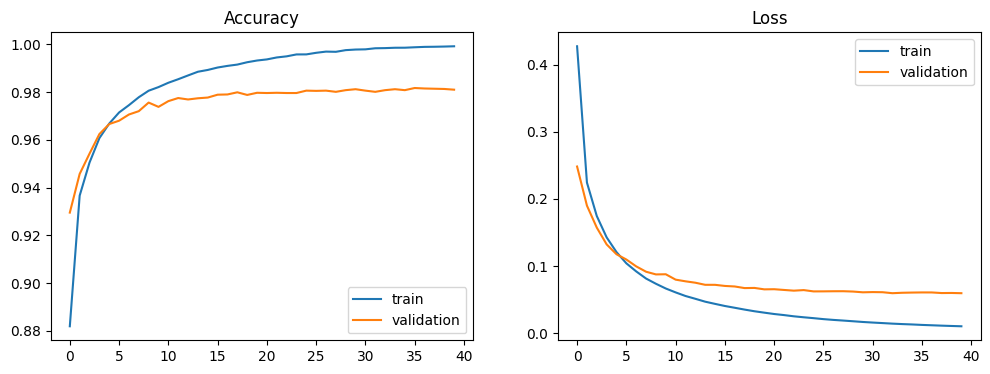


Optimizer: Adam
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9284 - loss: 0.2494 - val_accuracy: 0.9602 - val_loss: 0.1325
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9707 - loss: 0.1006 - val_accuracy: 0.9740 - val_loss: 0.0836
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9805 - loss: 0.0643 - val_accuracy: 0.9798 - val_loss: 0.0671
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9870 - loss: 0.0453 - val_accuracy: 0.9754 - val_loss: 0.0756
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9909 - loss: 0.0323 - val_accuracy: 0.9814 - val_loss: 0.0559
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9929 - loss: 0.0243 - val_accuracy: 0.9801 - val_loss: 0.0611
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9948 - loss: 0.0184 - val_accuracy: 0.9818 - val_loss: 0.0583
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9955 - loss: 0.0157 -

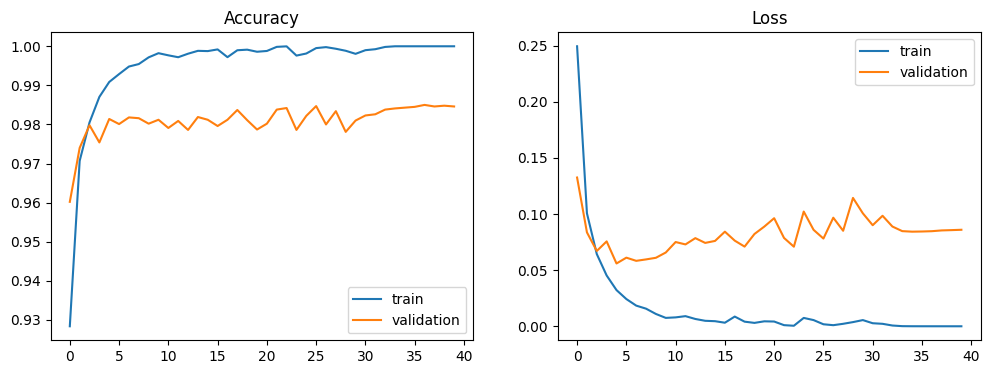

In [4]:
x_train, y_train, x_test, y_test = load_dataset("MNIST")

dense_mnist = dense_model(hidden=(500, 500))
dense_mnist.summary()
plot_model(dense_mnist, show_shapes=True, show_layer_names=False, show_layer_activations=True)

for optimizer in [
    tf.keras.optimizers.SGD(momentum=0.9),
    tf.keras.optimizers.Adam(),
]:
    print("\nOptimizer:", optimizer.__class__.__name__)

    model = dense_model()
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=40,
        batch_size=100,
        verbose=1,
        validation_data=(x_test, y_test),
    )

    print_best_metrics(history.history)
    plot_results(history)

Reference peak validation accuracies from prior runs were approximately **0.9818 with SGD + momentum** and **0.9849 with Adam**.

### 2.2 Fashion-MNIST: SGD + Momentum vs Adam

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Optimizer: SGD
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7972 - loss: 0.5907 - val_accuracy: 0.8326 - val_loss: 0.4733
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8490 - loss: 0.4324 - val_accuracy: 0.8399 - val_loss: 0.4484
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8640 - loss: 0.3915 - val_accuracy: 0.8540 - val_loss: 0.4127
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8730 - loss: 0.3643 - val_accuracy: 0.8573 - val_loss: 0.4004
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8771 - loss: 0.3460 - val_accuracy: 0.8690 - val_loss: 0.3739
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8842 - loss: 0.3305 - val_accuracy: 0.8607 - val_loss: 0.3904
Epoch 7/40
600/600 ━━━━━━━━━

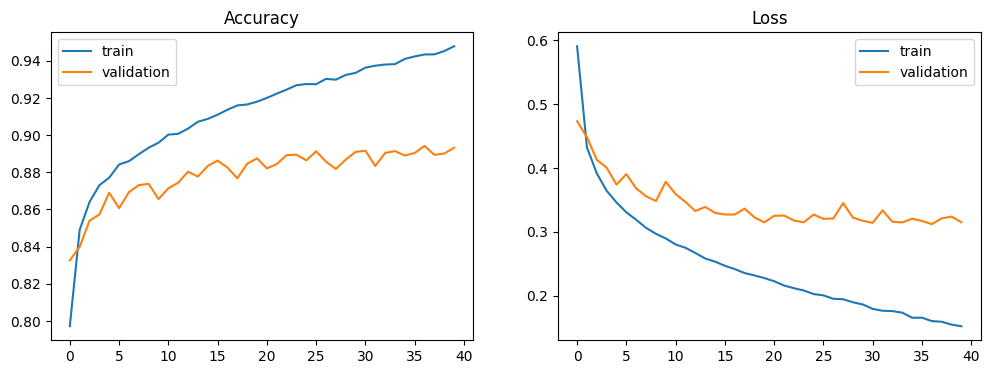


Optimizer: Adam
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8265 - loss: 0.4976 - val_accuracy: 0.8535 - val_loss: 0.4122
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8676 - loss: 0.3699 - val_accuracy: 0.8555 - val_loss: 0.3936
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.3283 - val_accuracy: 0.8660 - val_loss: 0.3658
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8880 - loss: 0.3043 - val_accuracy: 0.8706 - val_loss: 0.3604
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8944 - loss: 0.2862 - val_accuracy: 0.8711 - val_loss: 0.3515
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9000 - loss: 0.2715 - val_accuracy: 0.8777 - val_loss: 0.3461
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9047 - loss: 0.2588 - val_accuracy: 0.8840 - val_loss: 0.3262
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9079 - loss: 0.2469 -

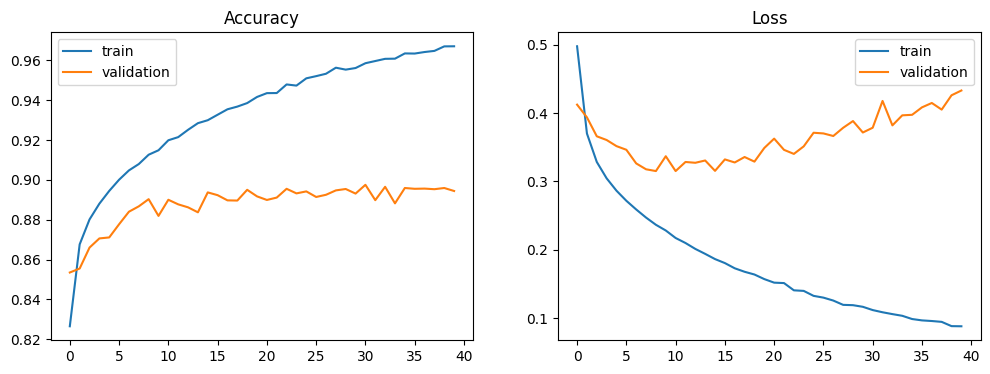

In [5]:
x_train, y_train, x_test, y_test = load_dataset("Fashion-MNIST")

for optimizer in [
    tf.keras.optimizers.SGD(momentum=0.9),
    tf.keras.optimizers.Adam(),
]:
    print("\nOptimizer:", optimizer.__class__.__name__)

    model = dense_model()
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=40,
        batch_size=100,
        verbose=1,
        validation_data=(x_test, y_test),
    )

    print_best_metrics(history.history)
    plot_results(history)

Reference peak validation accuracies were approximately **0.8962 with SGD + momentum** and **0.8999 with Adam**.

### 2.3 CIFAR-10: Dense-Network Baseline

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1784s 10us/step
Training images: (50000, 32, 32, 3)


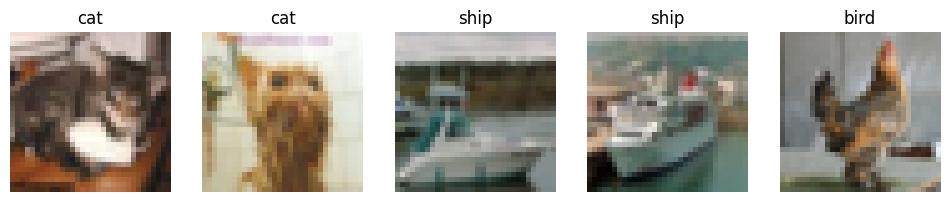

In [6]:
x_train, y_train, x_test, y_test = load_dataset("CIFAR-10")

print("Training images:", x_train.shape)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

rng = np.random.default_rng(42)
selected = rng.integers(0, x_train.shape[0], size=5)

fig, ax = plt.subplots(1, len(selected), figsize=(12, 3))
for i, idx in enumerate(selected):
    ax[i].imshow(x_train[idx])
    ax[i].set_title(class_names[int(y_train[idx, 0])])
    ax[i].axis("off")
plt.show()


Optimizer: SGD
Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3407 - loss: 1.8393 - val_accuracy: 0.3932 - val_loss: 1.6847
Epoch 2/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4109 - loss: 1.6560 - val_accuracy: 0.4324 - val_loss: 1.6033
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4379 - loss: 1.5877 - val_accuracy: 0.4278 - val_loss: 1.6046
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4568 - loss: 1.5330 - val_accuracy: 0.4270 - val_loss: 1.5991
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4663 - loss: 1.5024 - val_accuracy: 0.4647 - val_loss: 1.4976
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4825 - loss: 1.4642 - val_accuracy: 0.4590 - val_loss: 1.5185
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4934 - loss: 1.4322 - val_accuracy: 0.4776 - val_loss: 1.4642
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5013 - loss: 1.4082 - 

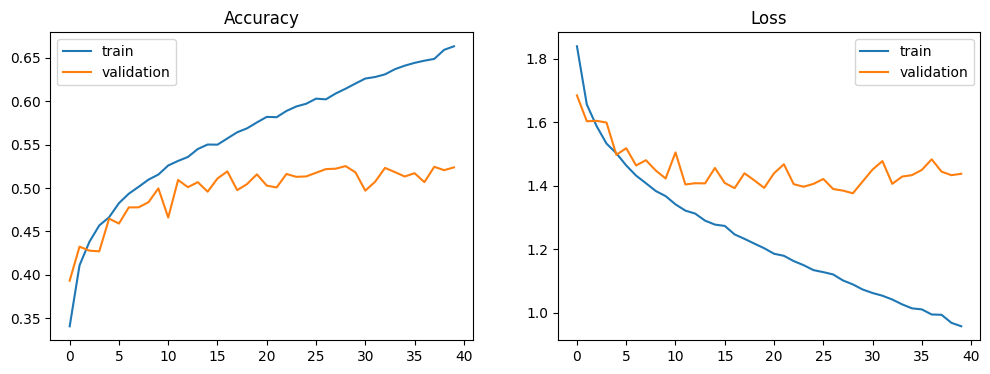


Optimizer: Adam
Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3250 - loss: 1.9226 - val_accuracy: 0.3898 - val_loss: 1.7230
Epoch 2/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3888 - loss: 1.7185 - val_accuracy: 0.4036 - val_loss: 1.6555
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4197 - loss: 1.6380 - val_accuracy: 0.4255 - val_loss: 1.6517
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4357 - loss: 1.5911 - val_accuracy: 0.4353 - val_loss: 1.6012
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4495 - loss: 1.5555 - val_accuracy: 0.4378 - val_loss: 1.5912
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4608 - loss: 1.5213 - val_accuracy: 0.4419 - val_loss: 1.5632
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4729 - loss: 1.4995 - val_accuracy: 0.4479 - val_loss: 1.5478
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4774 - loss: 1.4772 -

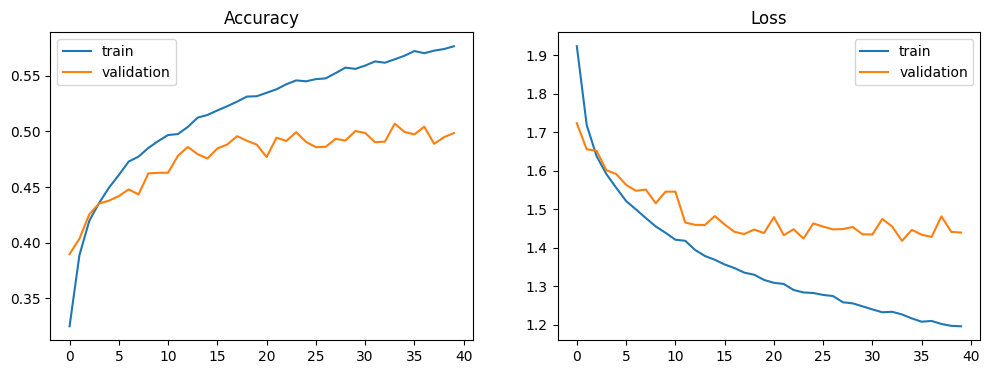

In [7]:
for optimizer in [
    tf.keras.optimizers.SGD(momentum=0.9),
    tf.keras.optimizers.Adam(),
]:
    print("\nOptimizer:", optimizer.__class__.__name__)

    model = dense_model(input_shape=x_train.shape[1:])
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=40,
        batch_size=100,
        verbose=1,
        validation_data=(x_test, y_test),
    )

    print_best_metrics(history.history)
    plot_results(history)

Reference peak validation accuracies were approximately **0.5287 with SGD + momentum** and **0.5085 with Adam**. The drop relative to MNIST and Fashion-MNIST highlights the limitation of flattening CIFAR-10 images before classification.

## 3. Sparse Labels vs One-Hot Labels

The same dense-network idea can also be trained with one-hot labels and categorical cross-entropy. This section keeps that formulation explicit because it is a useful contrast with sparse categorical labels.


Dataset: MNIST
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9226 - loss: 0.2649 - val_accuracy: 0.9586 - val_loss: 0.1309
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9732 - loss: 0.0912 - val_accuracy: 0.9712 - val_loss: 0.0935
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0574 - val_accuracy: 0.9762 - val_loss: 0.0782
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9765 - val_loss: 0.0772
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0271 - val_accuracy: 0.9771 - val_loss: 0.0771
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0234 - val_accuracy: 0.9800 - val_loss: 0.0709
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9955 - loss: 0.0148 - val_accuracy: 0.9789 - val_loss: 0.0818
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9956 - loss: 0.0131 

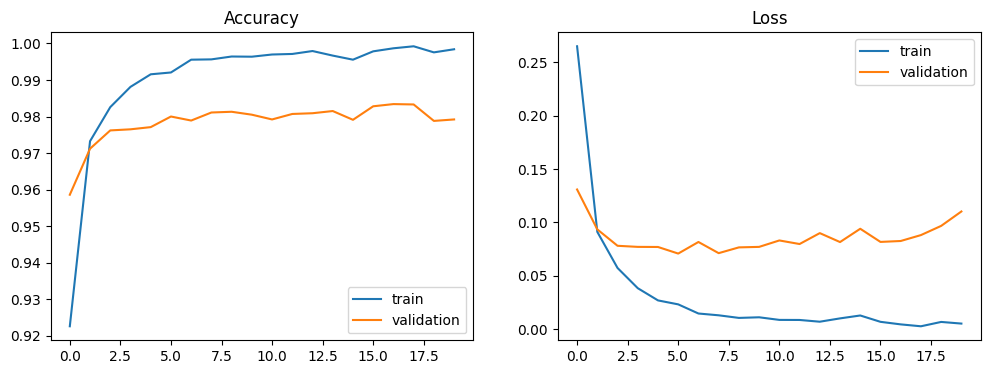


Dataset: Fashion-MNIST
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8195 - loss: 0.5076 - val_accuracy: 0.8458 - val_loss: 0.4277
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8709 - loss: 0.3585 - val_accuracy: 0.8629 - val_loss: 0.3744
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8842 - loss: 0.3195 - val_accuracy: 0.8735 - val_loss: 0.3540
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8911 - loss: 0.2959 - val_accuracy: 0.8749 - val_loss: 0.3556
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8983 - loss: 0.2769 - val_accuracy: 0.8777 - val_loss: 0.3374
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.2628 - val_accuracy: 0.8856 - val_loss: 0.3286
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9081 - loss: 0.2448 - val_accuracy: 0.8822 - val_loss: 0.3313
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9122 - loss: 

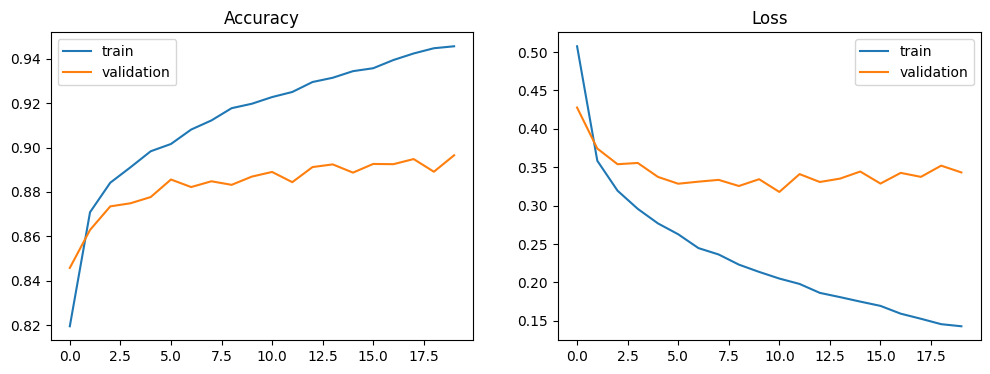


Dataset: CIFAR-10
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.3048 - loss: 1.9531 - val_accuracy: 0.3720 - val_loss: 1.7526
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4026 - loss: 1.6789 - val_accuracy: 0.4082 - val_loss: 1.6379
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4316 - loss: 1.5998 - val_accuracy: 0.4415 - val_loss: 1.5704
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4550 - loss: 1.5364 - val_accuracy: 0.4618 - val_loss: 1.5053
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4708 - loss: 1.4878 - val_accuracy: 0.4528 - val_loss: 1.5537
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4804 - loss: 1.4565 - val_accuracy: 0.4655 - val_loss: 1.5086
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4941 - loss: 1.4262 - val_accuracy: 0.4868 - val_loss: 1.4619
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5063 - loss: 1.39

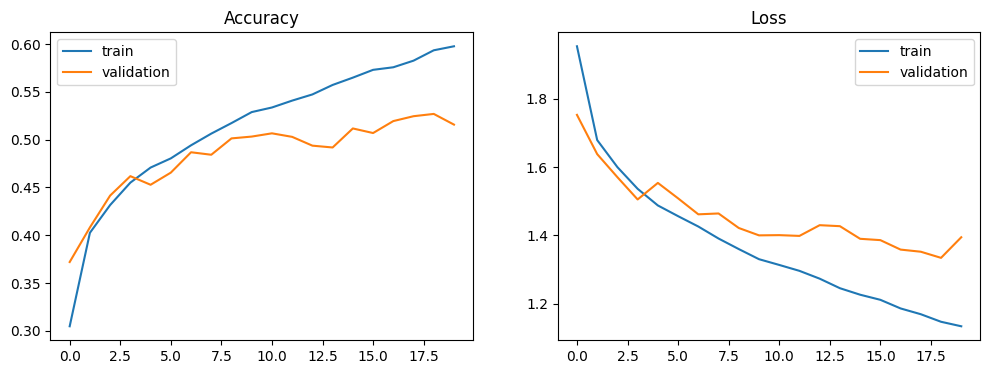

In [8]:
def load_dataset_onehot(name):
    x_train, y_train, x_test, y_test = load_dataset(name, add_channel=True)

    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test = tf.keras.utils.to_categorical(y_test, 10)

    return x_train, y_train, x_test, y_test


def dense_model_onehot(inputs=784, hidden_1=500, hidden_2=500):
    return Sequential([
        Input(shape=(inputs,)),
        Dense(hidden_1, activation="relu"),
        Dense(hidden_2, activation="relu"),
        Dense(10, activation="softmax"),
    ])


for dataset_name in ["MNIST", "Fashion-MNIST", "CIFAR-10"]:
    print("\nDataset:", dataset_name)

    x_train_oh, y_train_oh, x_test_oh, y_test_oh = load_dataset_onehot(dataset_name)

    x_train_flat = x_train_oh.reshape(x_train_oh.shape[0], -1)
    x_test_flat = x_test_oh.reshape(x_test_oh.shape[0], -1)

    model = dense_model_onehot(inputs=x_train_flat.shape[1])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train_flat,
        y_train_oh,
        epochs=20,
        batch_size=256,
        verbose=1,
        validation_data=(x_test_flat, y_test_oh),
    )

    print("Final training accuracy: {:.4f}".format(history.history["accuracy"][-1]))
    print("Final validation accuracy: {:.4f}".format(history.history["val_accuracy"][-1]))
    plot_results(history)

Reference final validation accuracies for the one-hot dense formulation were approximately **0.9815 on MNIST**, **0.8554 on Fashion-MNIST**, and **0.4914 on CIFAR-10**.

## 4. Dense Network vs Compact CNN

In [9]:
def cnn_model(input_shape=(28, 28, 1), conv_units=(32, 64)):
    model = Sequential([Input(shape=input_shape)])

    for filters in conv_units:
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(10, activation="softmax"))

    return model

### 4.1 MNIST

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)


Optimizer: SGD
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8800 - loss: 0.3823 - val_accuracy: 0.9673 - val_loss: 0.1054
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9744 - loss: 0.0829 - val_accuracy: 0.9814 - val_loss: 0.0611
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9823 - loss: 0.0575 - val_accuracy: 0.9843 - val_loss: 0.0454
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9857 - loss: 0.0455 - val_accuracy: 0.9876 - val_loss: 0.0351
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9885 - loss: 0.0378 - val_accuracy: 0.9893 - val_loss: 0.0322
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9903 - loss: 0.0324 - val_accuracy: 0.9884 - val_loss: 0.0360
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9919 - loss: 0.0267 - val_accuracy: 0.9888 - val_loss: 0.0333
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9925 - loss: 0.0239 - 

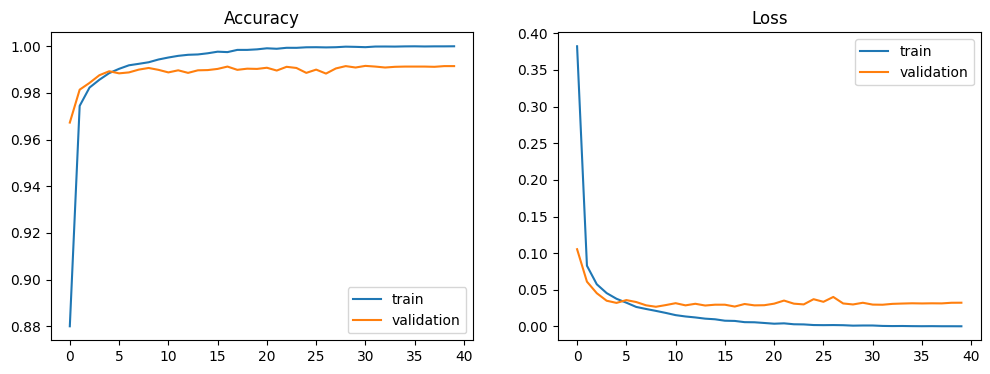


Optimizer: Adam
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9435 - loss: 0.1884 - val_accuracy: 0.9787 - val_loss: 0.0631
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9827 - loss: 0.0561 - val_accuracy: 0.9842 - val_loss: 0.0486
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9882 - loss: 0.0390 - val_accuracy: 0.9889 - val_loss: 0.0325
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9909 - loss: 0.0295 - val_accuracy: 0.9896 - val_loss: 0.0315
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9930 - loss: 0.0224 - val_accuracy: 0.9886 - val_loss: 0.0359
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.9896 - val_loss: 0.0321
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9953 - loss: 0.0142 - val_accuracy: 0.9894 - val_loss: 0.0338
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9962 - loss: 0.0120 -

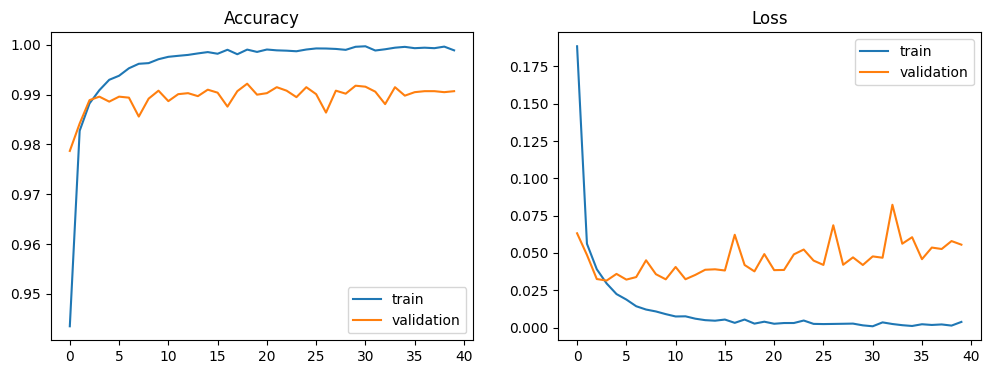

In [10]:
x_train, y_train, x_test, y_test = load_dataset("MNIST", add_channel=True)

model = cnn_model()
model.summary()
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

for optimizer in [
    tf.keras.optimizers.SGD(momentum=0.9),
    tf.keras.optimizers.Adam(),
]:
    print("\nOptimizer:", optimizer.__class__.__name__)

    model = cnn_model()
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=40,
        batch_size=100,
        verbose=1,
        validation_data=(x_test, y_test),
    )

    print_best_metrics(history.history)
    plot_results(history)

Reference peak validation accuracies were approximately **0.9915 with SGD + momentum** and **0.9933 with Adam**.

### 4.2 Fashion-MNIST


Optimizer: SGD
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7658 - loss: 0.6599 - val_accuracy: 0.8457 - val_loss: 0.4398
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8636 - loss: 0.3792 - val_accuracy: 0.8662 - val_loss: 0.3792
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8817 - loss: 0.3250 - val_accuracy: 0.8818 - val_loss: 0.3324
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8927 - loss: 0.2963 - val_accuracy: 0.8732 - val_loss: 0.3368
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9005 - loss: 0.2737 - val_accuracy: 0.8877 - val_loss: 0.3086
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9066 - loss: 0.2579 - val_accuracy: 0.8957 - val_loss: 0.2928
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9111 - loss: 0.2423 - val_accuracy: 0.8986 - val_loss: 0.2751
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9170 - loss: 0.2290 - 

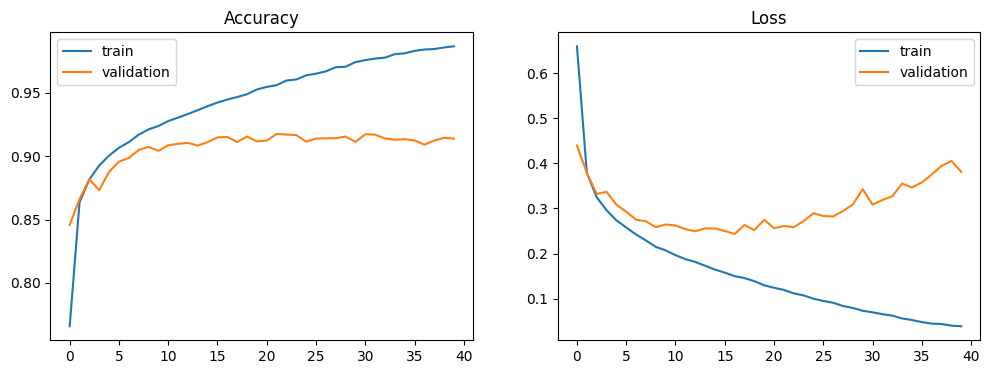


Optimizer: Adam
Epoch 1/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8249 - loss: 0.4897 - val_accuracy: 0.8652 - val_loss: 0.3797
Epoch 2/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8870 - loss: 0.3169 - val_accuracy: 0.8907 - val_loss: 0.3097
Epoch 3/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9033 - loss: 0.2690 - val_accuracy: 0.8987 - val_loss: 0.2783
Epoch 4/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9120 - loss: 0.2431 - val_accuracy: 0.9005 - val_loss: 0.2776
Epoch 5/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9217 - loss: 0.2177 - val_accuracy: 0.9092 - val_loss: 0.2523
Epoch 6/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9271 - loss: 0.2005 - val_accuracy: 0.9124 - val_loss: 0.2480
Epoch 7/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9320 - loss: 0.1851 - val_accuracy: 0.9152 - val_loss: 0.2329
Epoch 8/40
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9376 - loss: 0.1697 -

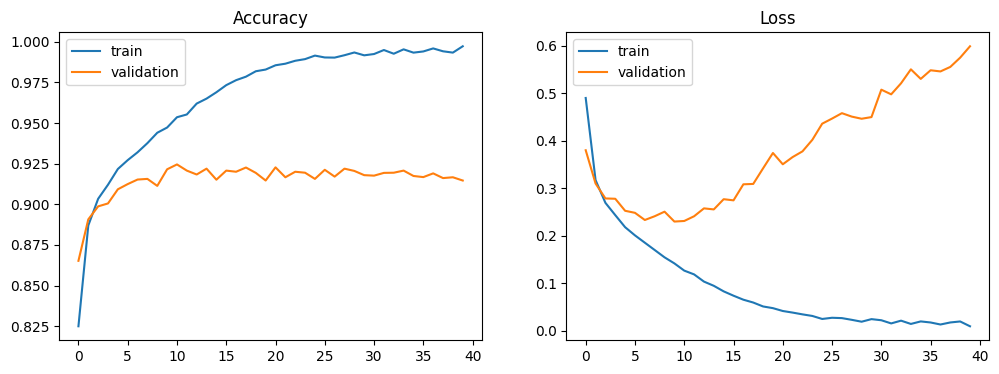

In [11]:
x_train, y_train, x_test, y_test = load_dataset("Fashion-MNIST", add_channel=True)

for optimizer in [
    tf.keras.optimizers.SGD(momentum=0.9),
    tf.keras.optimizers.Adam(),
]:
    print("\nOptimizer:", optimizer.__class__.__name__)

    model = cnn_model()
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=40,
        batch_size=100,
        verbose=1,
        validation_data=(x_test, y_test),
    )

    print_best_metrics(history.history)
    plot_results(history)

Reference peak validation accuracy was approximately **0.9198–0.9199** for the two optimizers.

### 4.3 CIFAR-10


Optimizer: SGD
Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3723 - loss: 1.7417 - val_accuracy: 0.4946 - val_loss: 1.3955
Epoch 2/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5374 - loss: 1.3024 - val_accuracy: 0.5687 - val_loss: 1.2117
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6033 - loss: 1.1160 - val_accuracy: 0.6090 - val_loss: 1.0901
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6486 - loss: 0.9989 - val_accuracy: 0.6278 - val_loss: 1.0666
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6841 - loss: 0.8991 - val_accuracy: 0.6604 - val_loss: 0.9763
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7093 - loss: 0.8273 - val_accuracy: 0.6713 - val_loss: 0.9636
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7340 - loss: 0.7553 - val_accuracy: 0.6850 - val_loss: 0.9213
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7557 - loss: 0.6962 - 

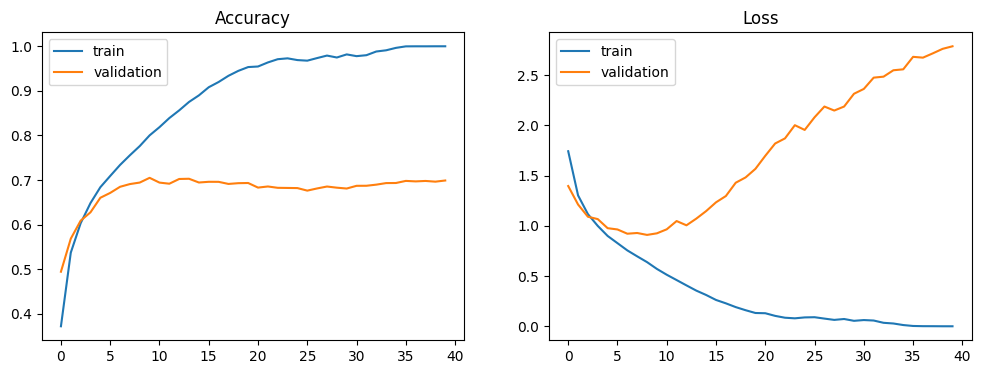


Optimizer: Adam
Epoch 1/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4561 - loss: 1.5200 - val_accuracy: 0.5575 - val_loss: 1.2437
Epoch 2/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5971 - loss: 1.1505 - val_accuracy: 0.6129 - val_loss: 1.0940
Epoch 3/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6479 - loss: 1.0098 - val_accuracy: 0.6523 - val_loss: 0.9920
Epoch 4/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6788 - loss: 0.9257 - val_accuracy: 0.6642 - val_loss: 0.9583
Epoch 5/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7008 - loss: 0.8636 - val_accuracy: 0.6939 - val_loss: 0.8972
Epoch 6/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7182 - loss: 0.8108 - val_accuracy: 0.6872 - val_loss: 0.8980
Epoch 7/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7367 - loss: 0.7598 - val_accuracy: 0.7013 - val_loss: 0.8805
Epoch 8/40
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7528 - loss: 0.7160 -

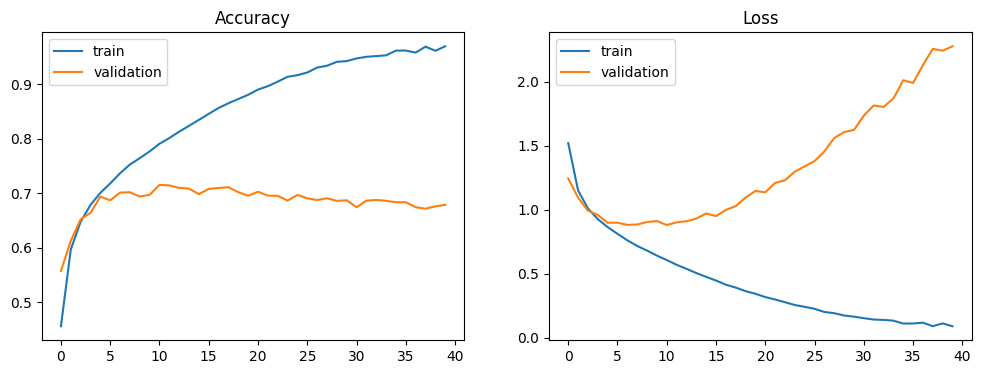

In [12]:
x_train, y_train, x_test, y_test = load_dataset("CIFAR-10")

for optimizer in [
    tf.keras.optimizers.SGD(momentum=0.9),
    tf.keras.optimizers.Adam(),
]:
    print("\nOptimizer:", optimizer.__class__.__name__)

    model = cnn_model(input_shape=x_train.shape[1:])
    model.compile(
        optimizer=optimizer,
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=40,
        batch_size=100,
        verbose=1,
        validation_data=(x_test, y_test),
    )

    print_best_metrics(history.history)
    plot_results(history)

Reference peak validation accuracies were approximately **0.6966 with SGD + momentum** and **0.7115 with Adam**.

## 5. CNN Architecture Comparison: With vs Without Dense Hidden Layer


Dataset: MNIST
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8949 - loss: 0.3912 - val_accuracy: 0.9707 - val_loss: 0.1059
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.0917 - val_accuracy: 0.9816 - val_loss: 0.0611
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9807 - loss: 0.0648 - val_accuracy: 0.9823 - val_loss: 0.0528
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9838 - loss: 0.0541 - val_accuracy: 0.9862 - val_loss: 0.0423
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9869 - loss: 0.0443 - val_accuracy: 0.9855 - val_loss: 0.0416
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0402 - val_accuracy: 0.9826 - val_loss: 0.0530
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9897 - loss: 0.0359 - val_accuracy: 0.9873 - val_loss: 0.0345
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9906 - loss: 0.0316 -

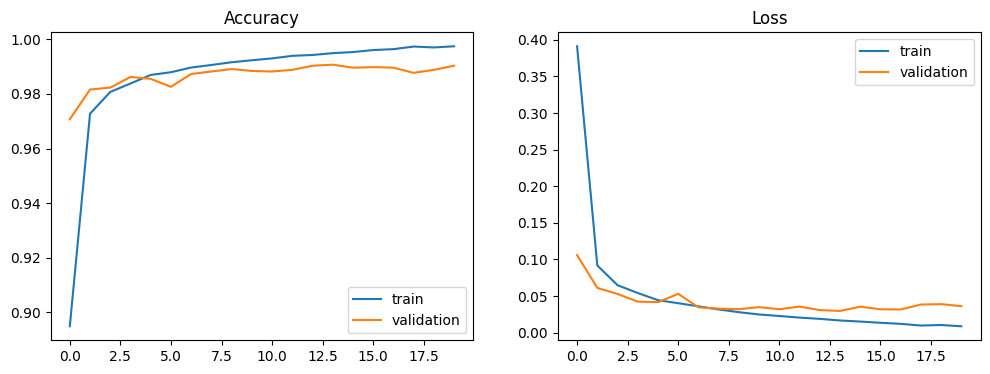


Dataset: Fashion-MNIST
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7537 - loss: 0.7166 - val_accuracy: 0.8256 - val_loss: 0.4795
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8486 - loss: 0.4252 - val_accuracy: 0.8566 - val_loss: 0.4064
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8702 - loss: 0.3679 - val_accuracy: 0.8682 - val_loss: 0.3736
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8806 - loss: 0.3390 - val_accuracy: 0.8716 - val_loss: 0.3526
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8863 - loss: 0.3199 - val_accuracy: 0.8789 - val_loss: 0.3382
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8916 - loss: 0.3018 - val_accuracy: 0.8832 - val_loss: 0.3281
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8967 - loss: 0.2898 - val_accuracy: 0.8829 - val_loss: 0.3181
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9010 - loss: 

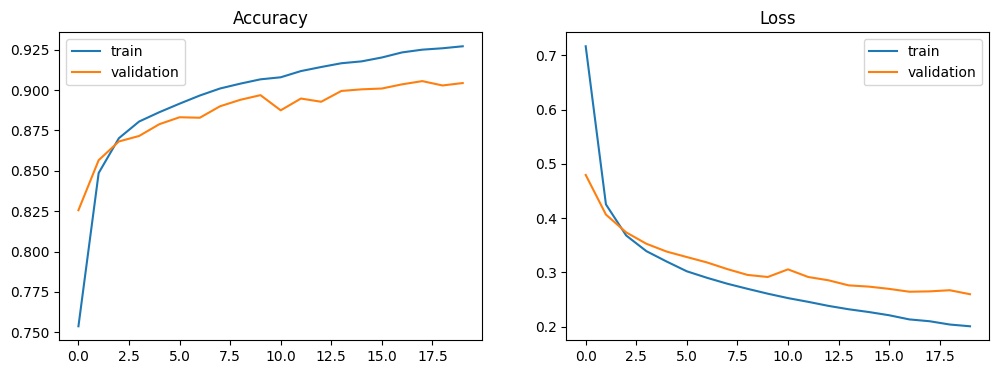


Dataset: CIFAR-10
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3895 - loss: 1.7081 - val_accuracy: 0.4911 - val_loss: 1.4443
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5192 - loss: 1.3701 - val_accuracy: 0.5401 - val_loss: 1.3204
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5647 - loss: 1.2589 - val_accuracy: 0.5761 - val_loss: 1.2255
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5903 - loss: 1.1805 - val_accuracy: 0.6029 - val_loss: 1.1476
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6122 - loss: 1.1251 - val_accuracy: 0.6075 - val_loss: 1.1344
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6277 - loss: 1.0789 - val_accuracy: 0.6261 - val_loss: 1.0867
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6399 - loss: 1.0443 - val_accuracy: 0.6374 - val_loss: 1.0503
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6522 - loss: 1.012

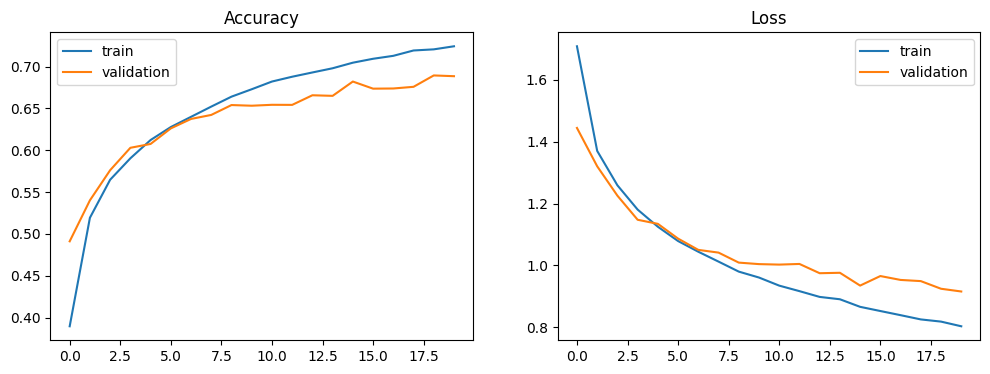

In [13]:
def simple_cnn(input_shape):
    return Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(10, activation="softmax"),
    ])


for dataset_name in ["MNIST", "Fashion-MNIST", "CIFAR-10"]:
    print("\nDataset:", dataset_name)

    x_train, y_train, x_test, y_test = load_dataset(
        dataset_name,
        add_channel=dataset_name != "CIFAR-10",
    )

    y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
    y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

    model = simple_cnn(x_train.shape[1:])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train_oh,
        epochs=20,
        batch_size=256,
        verbose=1,
        validation_data=(x_test, y_test_oh),
    )

    print("Final training accuracy: {:.4f}".format(history.history["accuracy"][-1]))
    print("Final validation accuracy: {:.4f}".format(history.history["val_accuracy"][-1]))
    plot_results(history)

A longer 100-epoch CIFAR-10 run of this compact architecture previously reached about **0.7603 validation accuracy**.

## 6. Compact CNN vs Deeper VGG-Style CNN


Dataset: MNIST
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9158 - loss: 0.2640 - val_accuracy: 0.9858 - val_loss: 0.0448
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9847 - loss: 0.0495 - val_accuracy: 0.9879 - val_loss: 0.0359
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 0.9937 - val_loss: 0.0210
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9923 - loss: 0.0243 - val_accuracy: 0.9922 - val_loss: 0.0259
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9939 - loss: 0.0196 - val_accuracy: 0.9924 - val_loss: 0.0224
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9952 - loss: 0.0148 - val_accuracy: 0.9921 - val_loss: 0.0220
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9959 - loss: 0.0121 - val_accuracy: 0.9921 - val_loss: 0.0257
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9962 - loss: 0.0113 

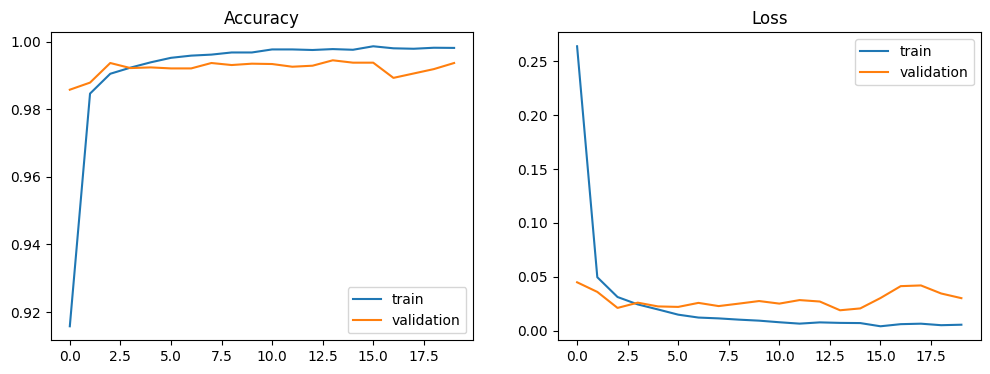


Dataset: Fashion-MNIST
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7666 - loss: 0.6431 - val_accuracy: 0.8598 - val_loss: 0.3793
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8812 - loss: 0.3257 - val_accuracy: 0.8809 - val_loss: 0.3205
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9025 - loss: 0.2679 - val_accuracy: 0.9004 - val_loss: 0.2734
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9156 - loss: 0.2311 - val_accuracy: 0.9016 - val_loss: 0.2677
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9244 - loss: 0.2057 - val_accuracy: 0.9148 - val_loss: 0.2338
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9328 - loss: 0.1820 - val_accuracy: 0.9180 - val_loss: 0.2307
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9399 - loss: 0.1651 - val_accuracy: 0.9244 - val_loss: 0.2156
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9460 - loss:

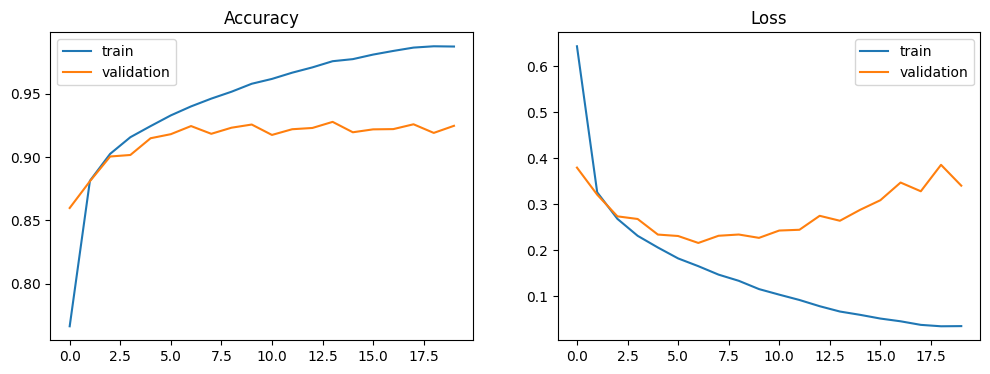


Dataset: CIFAR-10
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.3856 - loss: 1.6689 - val_accuracy: 0.4628 - val_loss: 1.5127
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5650 - loss: 1.2041 - val_accuracy: 0.6106 - val_loss: 1.0996
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6612 - loss: 0.9549 - val_accuracy: 0.6844 - val_loss: 0.9118
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7211 - loss: 0.7960 - val_accuracy: 0.7159 - val_loss: 0.8339
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7631 - loss: 0.6773 - val_accuracy: 0.7355 - val_loss: 0.7758
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7943 - loss: 0.5898 - val_accuracy: 0.7548 - val_loss: 0.7084
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8246 - loss: 0.5080 - val_accuracy: 0.7616 - val_loss: 0.7032
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8460 - loss: 0.44

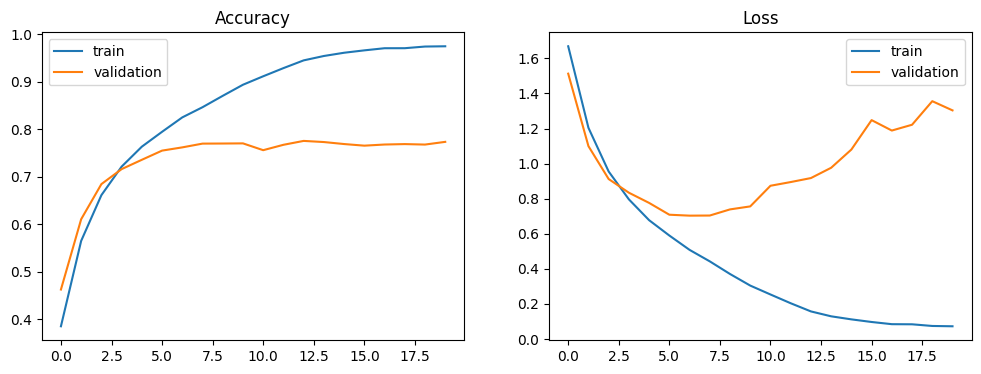

In [14]:
def deeper_cnn(input_shape):
    return Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), padding="same", activation="relu"),
        Conv2D(32, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), padding="same", activation="relu"),
        Conv2D(64, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), padding="same", activation="relu"),
        Conv2D(128, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax"),
    ])


for dataset_name in ["MNIST", "Fashion-MNIST", "CIFAR-10"]:
    print("\nDataset:", dataset_name)

    x_train, y_train, x_test, y_test = load_dataset(
        dataset_name,
        add_channel=dataset_name != "CIFAR-10",
    )

    y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
    y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

    model = deeper_cnn(x_train.shape[1:])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train_oh,
        epochs=20,
        batch_size=256,
        verbose=1,
        validation_data=(x_test, y_test_oh),
    )

    print("Final training accuracy: {:.4f}".format(history.history["accuracy"][-1]))
    print("Final validation accuracy: {:.4f}".format(history.history["val_accuracy"][-1]))
    plot_results(history)

Reference final validation accuracies for this deeper formulation were approximately **0.9936 on MNIST**, **0.9237 on Fashion-MNIST**, and **0.7406 on CIFAR-10**.

## 7. Cross-Dataset Comparison Summary

The experiments show a clear progression. Dense networks are very effective on MNIST, remain competitive on Fashion-MNIST, but lose substantial information when CIFAR-10 is flattened. CNNs preserve local spatial structure and improve the CIFAR-10 results substantially. The optimizer comparisons also show that architecture and data representation generally matter more than simply switching between SGD and Adam.